1.	Table 1 shows the first five lines of the dataset in the file lines.csv. It represents three points scatters conforming to three lines. The coordinates of the points are stored in columns x1, x2, x3, y1, y2, and y3.

In [7]:
import pandas as pd
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("lines.csv")

In [17]:
df.head()

,x1,x2,x3,y1,y2,y3
0,-5.31,-4.06,-5.26,-12.7,-3.80,3.691712
1,-5.54,-5.00,-3.99,-11.0,-3.99,4.900004
2,-4.98,-4.58,-4.33,-11.7,-3.59,5.046863
3,-4.50,-5.06,-4.78,-12.0,-3.60,4.635936
4,-4.44,-4.41,-4.57,-12.4,-2.80,4.739699


(a)	Use total least squares to fit the lines to only using the data corresponding to the first line. Report the resulting parameters.

In [18]:
x1 = df["x1"].values
y1 = df["y1"].values

print("Number of points:", len(x1))

Number of points: 100


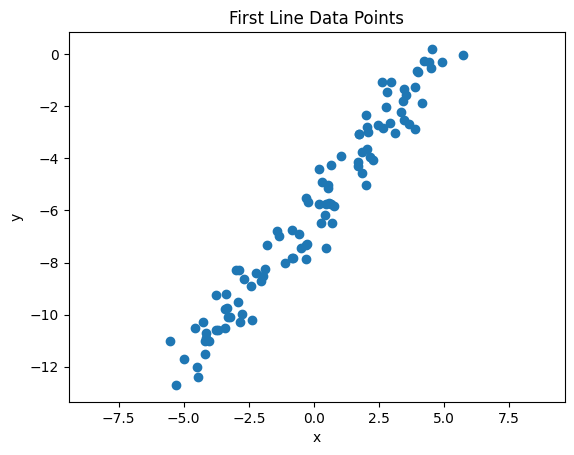

In [19]:
plt.figure()
plt.scatter(x1, y1)
plt.title("First Line Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [20]:
# Step 1: Compute centroid
x_mean = np.mean(x1)
y_mean = np.mean(y1)

# Step 2: Center data
X = np.vstack((x1 - x_mean, y1 - y_mean)).T

# Step 3: Perform SVD
U, S, Vt = np.linalg.svd(X)

# Step 4: Extract normal vector
a, b = Vt[-1]
c = -(a*x_mean + b*y_mean)

In [21]:
print("Line parameters using Total Least Squares method:")
print(f"{a:.4f}x + {b:.4f}y + {c:.4f} = 0")

Line parameters using Total Least Squares method:
0.7739x + -0.6333y + -3.7933 = 0


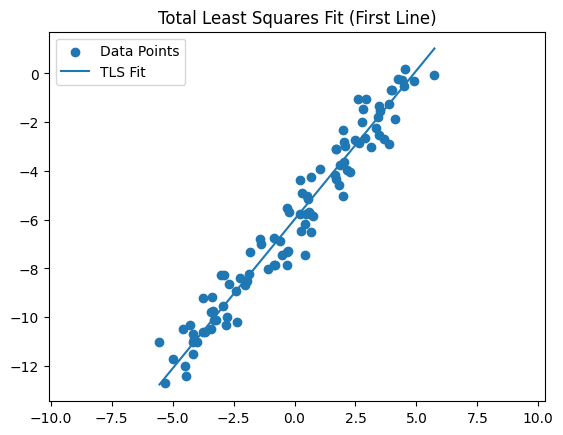

In [22]:
# Visualize the line 0.7739x + -0.6333y + -3.7933 = 0

# Generate line for plotting
x_vals = np.linspace(min(x1), max(x1), 200)

# Avoid division by zero
if abs(b) > 1e-6:
    y_vals = -(a*x_vals + c)/b
    plt.figure()
    plt.scatter(x1, y1, label="Data Points")
    plt.plot(x_vals, y_vals, label="TLS Fit")
else:
    # vertical line case
    x_vals = -c/a * np.ones_like(x_vals)
    y_vals = np.linspace(min(y1), max(y1), 200)
    plt.figure()
    plt.scatter(x1, y1, label="Data Points")
    plt.plot(x_vals, y_vals, label="TLS Fit")

plt.legend()
plt.title("Total Least Squares Fit (First Line)")
plt.axis("equal")
plt.show()

(b)	Now, use all the points as indicate in the code snippet below and fit three lines. Hint: Run RANSAC to find a line, mask the consensus and run again and so on to find the three lines

In [23]:
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

In [24]:
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

In [26]:
points = np.column_stack((X_all, Y_all))

print("Total points:", len(points))

Total points: 300


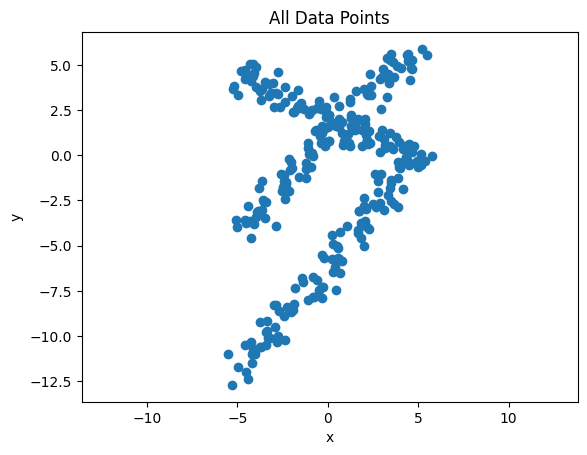

In [25]:
# Plot

plt.figure()
plt.scatter(X_all, Y_all)
plt.title("All Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [27]:
# Defining RANSAC function

def fit_line(p1, p2):
    a = p2[1] - p1[1]
    b = p1[0] - p2[0]
    c = -(a*p1[0] + b*p1[1])
    return a, b, c

def point_line_distance(a, b, c, x, y):
    return np.abs(a*x + b*y + c) / np.sqrt(a*a + b*b)

In [28]:
# Implement the RANSAC

def ransac_line(points, threshold=0.2, iterations=1000):
    best_inliers = []
    best_model = None

    n = len(points)

    for _ in range(iterations):
        # Randomly select two distinct points
        idx = np.random.choice(n, 2, replace=False)
        p1, p2 = points[idx]

        a, b, c = fit_line(p1, p2)

        distances = point_line_distance(a, b, c,
                                        points[:,0],
                                        points[:,1])

        inliers = points[distances < threshold]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)

    return best_model, best_inliers

In [29]:
# Extract 3 lines

remaining_points = points.copy()
models = []
all_inliers = []

for i in range(3):
    model, inliers = ransac_line(remaining_points)

    models.append(model)
    all_inliers.append(inliers)

    # Remove inliers for next iteration
    mask = np.ones(len(remaining_points), dtype=bool)

    for p in inliers:
        idx = np.where((remaining_points == p).all(axis=1))[0]
        mask[idx] = False

    remaining_points = remaining_points[mask]

    print(f"Line {i+1} parameters:")
    print(f"{model[0]:.4f}x + {model[1]:.4f}y + {model[2]:.4f} = 0\n")

Line 1 parameters:
5.9462x + -5.8022y + 5.1330 = 0

Line 2 parameters:
-0.6371x + -1.4688y + 3.1198 = 0

Line 3 parameters:
7.3800x + -5.7889y + -34.0404 = 0



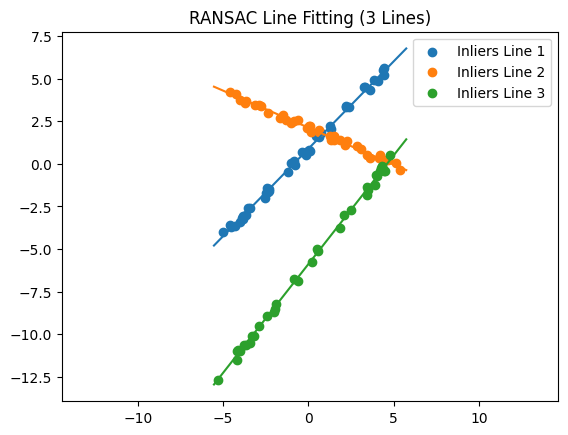

In [30]:
# Plot lines

plt.figure()

colors = ['r', 'g', 'b']

for i, (model, inliers) in enumerate(zip(models, all_inliers)):
    a, b, c = model

    plt.scatter(inliers[:,0], inliers[:,1], label=f"Inliers Line {i+1}")

    x_vals = np.linspace(min(X_all), max(X_all), 200)

    if abs(b) > 1e-6:
        y_vals = -(a*x_vals + c)/b
        plt.plot(x_vals, y_vals)
    else:
        x_line = -c/a * np.ones_like(x_vals)
        y_line = np.linspace(min(Y_all), max(Y_all), 200)
        plt.plot(x_line, y_line)

plt.title("RANSAC Line Fitting (3 Lines)")
plt.axis("equal")
plt.legend()
plt.show()

RANSAC successfully separated the three line structures despite the presence of structured outliers from other lines.

Unlike Total Least Squares, which assumes a single dominant model, RANSAC robustly estimates multiple geometric models by iteratively masking consensus sets.